# Fairness-Aware Training — Demo Notebook

This notebook demonstrates every component of the `training` module:

| # | Component | File |
|---|-----------|------|
| 1 | **ReductionsWrapper** | `reductions_wrapper.py` |
| 2 | **FairnessRegularizer** | `fairness_regularizer.py` |
| 3 | **LagrangianFairnessTrainer** | `lagrangian_trainer.py` |
| 4 | **GroupFairnessCalibrator** | `calibrator.py` |
| 5 | **Pareto Frontier** | `pareto.py` |
| 6 | **AdversarialDebiasingTrainer** *(stretch)* | `adversarial.py` |

---

## 0 · Setup & Shared Synthetic Data

We generate a **synthetic loan-approval dataset** with a built-in bias:
applicants from group A (`sensitive=0`) are systematically under-scored compared
to group B (`sensitive=1`) with equivalent real credentials.

In [1]:
# ── Imports ─────────────────────────────────────────────────────────────────
import sys, os, warnings
warnings.filterwarnings('ignore')

# ⚠️  Adjust this path if the `training` package lives elsewhere
sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, Dataset
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
print('✓ Imports OK')

✓ Imports OK


In [2]:
# ── Synthetic Data Generator ─────────────────────────────────────────────────
def make_loan_dataset(n=2000, bias=1.2, seed=42):
    """
    Binary classification: predict loan approval.
    Sensitive attribute: gender (0 = group A, 1 = group B).
    Bias: group B's income signal is inflated by `bias`, so a naive model
    learns to discriminate against group A.
    """
    rng = np.random.default_rng(seed)
    sensitive = rng.integers(0, 2, size=n).astype(float)

    # Real features
    income        = rng.normal(50, 15, n)
    credit_score  = rng.normal(650, 80, n)
    employment_yrs= rng.uniform(0, 20, n)
    debt_ratio    = rng.uniform(0.1, 0.9, n)

    # Biased score: group B gets an artificial boost
    score = (
        0.4 * (income / 50)
        + 0.3 * (credit_score / 650)
        - 0.2 * debt_ratio
        + 0.1 * (employment_yrs / 20)
        + bias * 0.3 * sensitive          # ← bias term
        + rng.normal(0, 0.15, n)
    )
    y = (score > score.mean()).astype(float)

    X = np.stack([income, credit_score, employment_yrs, debt_ratio], axis=1)
    # Normalise
    X = (X - X.mean(0)) / (X.std(0) + 1e-8)
    return X.astype(np.float32), y.astype(np.float32), sensitive.astype(np.float32)

X, y, sensitive = make_loan_dataset(n=2000)
(
    X_tr, X_val, y_tr, y_val, s_tr, s_val
) = train_test_split(X, y, sensitive, test_size=0.25, random_state=SEED)

print(f'Train: {X_tr.shape}  |  Val: {X_val.shape}')
print(f'Group A approval rate (train): {y_tr[s_tr==0].mean():.3f}')
print(f'Group B approval rate (train): {y_tr[s_tr==1].mean():.3f}')
print(f'Demographic parity gap       : {abs(y_tr[s_tr==0].mean()-y_tr[s_tr==1].mean()):.3f}')

Train: (1500, 4)  |  Val: (500, 4)
Group A approval rate (train): 0.214
Group B approval rate (train): 0.819
Demographic parity gap       : 0.605


In [3]:
# ── PyTorch helpers ───────────────────────────────────────────────────────────

class DictDataset(Dataset):
    """Wraps arrays into a dict-style Dataset expected by the trainers."""
    def __init__(self, X, y, sensitive, extra=None):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
        self.s = torch.tensor(sensitive, dtype=torch.float32)
        self.extra = extra or {}  # extra keys: {str: tensor}

    def __len__(self): return len(self.y)

    def __getitem__(self, idx):
        batch = {'X': self.X[idx], 'y': self.y[idx], 'sensitive': self.s[idx]}
        for k, v in self.extra.items():
            batch[k] = v[idx]
        return batch

def make_loaders(X_tr, y_tr, s_tr, X_val, y_val, s_val, batch=128):
    train_dl = DataLoader(DictDataset(X_tr, y_tr, s_tr), batch_size=batch, shuffle=True)
    val_dl   = DataLoader(DictDataset(X_val, y_val, s_val), batch_size=batch)
    return train_dl, val_dl

train_dl, val_dl = make_loaders(X_tr, y_tr, s_tr, X_val, y_val, s_val)

def make_mlp(in_dim=4, hidden=32, out_dim=1):
    return nn.Sequential(
        nn.Linear(in_dim, hidden), nn.ReLU(),
        nn.Linear(hidden, hidden), nn.ReLU(),
        nn.Linear(hidden, out_dim),
    )

def dp_gap(probs, sensitive):
    """Demographic parity gap between two groups."""
    g0 = probs[sensitive == 0].mean()
    g1 = probs[sensitive == 1].mean()
    return abs(g0 - g1)

print('✓ PyTorch helpers ready')

✓ PyTorch helpers ready


---
## 1 · ReductionsWrapper  (scikit-learn + fairlearn)

`ExponentiatedGradient` trains an *ensemble* of base classifiers, each weighted
to satisfy the fairness constraint.  We compare a baseline XGBoost with the
fairness-constrained version.

In [4]:
from reductions_wrapper import ReductionsWrapper
from fairlearn.reductions import DemographicParity, EqualizedOdds
from xgboost import XGBClassifier

# ── Baseline (unconstrained) ─────────────────────────────────────────────────
base = XGBClassifier(n_estimators=50, max_depth=3, random_state=SEED, verbosity=0)
base.fit(X_tr, y_tr)
base_preds = base.predict(X_val)
base_proba = base.predict_proba(X_val)[:, 1]

print('=== Baseline XGBoost ===')
print(f'  Accuracy  : {accuracy_score(y_val, base_preds):.4f}')
print(f'  DP Gap    : {dp_gap(base_proba, s_val):.4f}')

=== Baseline XGBoost ===
  Accuracy  : 0.6520
  DP Gap    : 0.0474


In [5]:
# ── Demographic Parity constraint ────────────────────────────────────────────
wrapper_dp = ReductionsWrapper(
    estimator=XGBClassifier(n_estimators=50, max_depth=3, random_state=SEED, verbosity=0),
    constraint=DemographicParity(),
    eps=0.02,
    max_iter=40,
)
wrapper_dp.fit(X_tr, y_tr, sensitive_features=s_tr)

dp_preds = wrapper_dp.predict(X_val)
dp_proba = wrapper_dp.predict_proba(X_val)[:, 1]

print('=== ReductionsWrapper (DemographicParity) ===')
print(f'  Accuracy  : {accuracy_score(y_val, dp_preds):.4f}')
print(f'  DP Gap    : {dp_gap(dp_proba, s_val):.4f}')
print(f'  Predictors: {len(wrapper_dp.predictors_)}')
print()
print(wrapper_dp.summary())

=== ReductionsWrapper (DemographicParity) ===
  Accuracy  : 0.6740
  DP Gap    : 0.0632
  Predictors: 8

=== ReductionsWrapper Summary ===
Constraint    : DemographicParity
eps           : 0.02
Predictors    : 8
Top weights   : [(np.float64(0.7325), 4), (np.float64(0.2675), 1), (np.float64(0.0), 7)]
Best estimator: predictor[4] (weight=0.7325)


In [6]:
# ── Equalized Odds constraint ────────────────────────────────────────────────
wrapper_eo = ReductionsWrapper(
    estimator=XGBClassifier(n_estimators=50, max_depth=3, random_state=SEED, verbosity=0),
    constraint=EqualizedOdds(),
    eps=0.02,
    max_iter=40,
)
wrapper_eo.fit(X_tr, y_tr, sensitive_features=s_tr)

eo_preds = wrapper_eo.predict(X_val)
eo_proba = wrapper_eo.predict_proba(X_val)[:, 1]

print('=== ReductionsWrapper (EqualizedOdds) ===')
print(f'  Accuracy  : {accuracy_score(y_val, eo_preds):.4f}')
print(f'  DP Gap    : {dp_gap(eo_proba, s_val):.4f}')

=== ReductionsWrapper (EqualizedOdds) ===
  Accuracy  : 0.6260
  DP Gap    : 0.0469


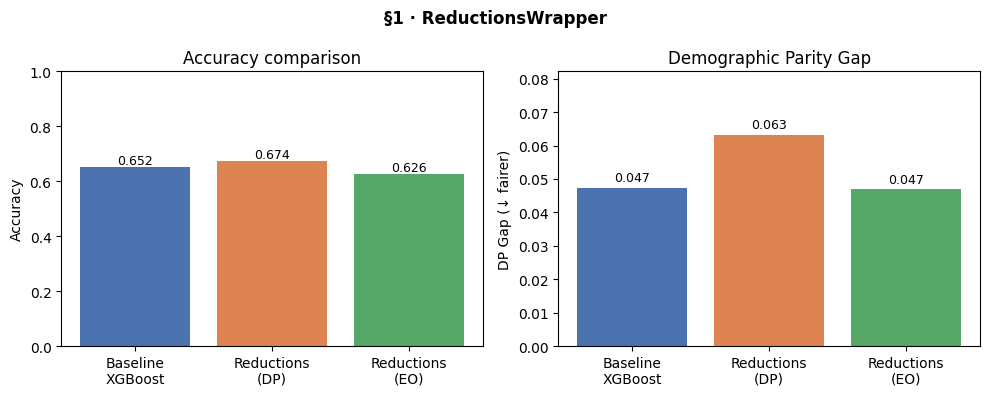

Figure saved → section1_reductions.png


In [7]:
# ── Side-by-side bar chart ────────────────────────────────────────────────────
models   = ['Baseline\nXGBoost', 'Reductions\n(DP)', 'Reductions\n(EO)']
accs     = [
    accuracy_score(y_val, base_preds),
    accuracy_score(y_val, dp_preds),
    accuracy_score(y_val, eo_preds),
]
gaps     = [dp_gap(base_proba, s_val), dp_gap(dp_proba, s_val), dp_gap(eo_proba, s_val)]

x = np.arange(len(models))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.bar(x, accs, color=['#4C72B0', '#DD8452', '#55A868'])
ax1.set_xticks(x); ax1.set_xticklabels(models)
ax1.set_ylabel('Accuracy'); ax1.set_title('Accuracy comparison')
ax1.set_ylim(0, 1)
for i, v in enumerate(accs): ax1.text(i, v+0.01, f'{v:.3f}', ha='center', fontsize=9)

ax2.bar(x, gaps, color=['#4C72B0', '#DD8452', '#55A868'])
ax2.set_xticks(x); ax2.set_xticklabels(models)
ax2.set_ylabel('DP Gap (↓ fairer)'); ax2.set_title('Demographic Parity Gap')
ax2.set_ylim(0, max(gaps)*1.3)
for i, v in enumerate(gaps): ax2.text(i, v+0.002, f'{v:.3f}', ha='center', fontsize=9)

plt.suptitle('§1 · ReductionsWrapper', fontweight='bold')
plt.tight_layout()
plt.savefig('section1_reductions.png', dpi=120, bbox_inches='tight')
plt.show()
print('Figure saved → section1_reductions.png')

---
## 2 · FairnessRegularizer  (PyTorch soft constraint)

We train a small MLP using the custom loss
$$\mathcal{L} = \text{BCE} + \eta \cdot \text{FairnessPenalty}$$
and compare different values of η.  The **stretch goal** intersectional
version is also demonstrated.

In [8]:
from fairness_regularizer import FairnessRegularizer

def train_with_regularizer(eta, epochs=30, lr=1e-3):
    model = make_mlp()
    opt   = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = FairnessRegularizer(eta=eta)

    for _ in range(epochs):
        model.train()
        for batch in train_dl:
            opt.zero_grad()
            logits = model(batch['X']).squeeze(-1)
            loss = loss_fn(logits, batch['y'], sensitive=batch['sensitive'])
            loss.backward()
            opt.step()

    # Evaluate
    model.eval()
    with torch.no_grad():
        X_t = torch.tensor(X_val)
        proba = torch.sigmoid(model(X_t).squeeze(-1)).numpy()
    preds = (proba >= 0.5).astype(int)
    acc   = accuracy_score(y_val, preds)
    gap   = dp_gap(proba, s_val)
    return acc, gap, model

eta_grid = [0.0, 0.1, 0.5, 1.0, 2.0]
reg_results = {}

print(f'{"η":>6}  {"Accuracy":>10}  {"DP Gap":>10}')
print('-' * 32)
for eta in eta_grid:
    acc, gap, mdl = train_with_regularizer(eta)
    reg_results[eta] = (acc, gap, mdl)
    print(f'{eta:>6.2f}  {acc:>10.4f}  {gap:>10.4f}')

     η    Accuracy      DP Gap
--------------------------------
  0.00      0.6820      0.0402
  0.10      0.6760      0.0439
  0.50      0.6780      0.0398
  1.00      0.6760      0.0430
  2.00      0.6900      0.0439


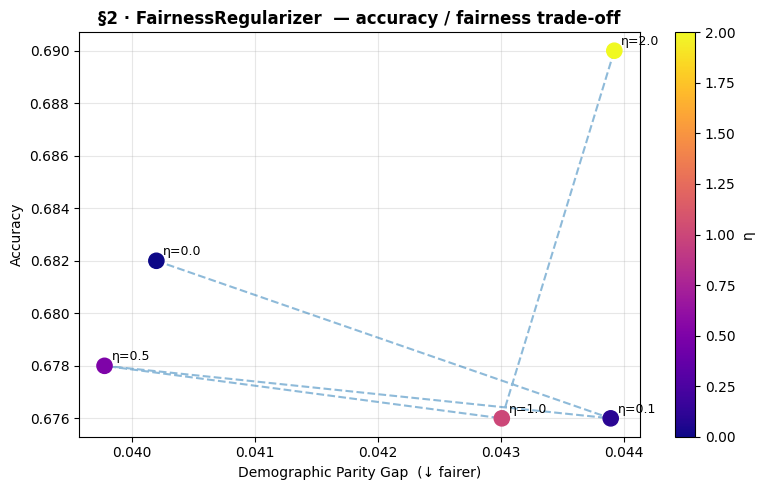

In [9]:
# ── Plot: accuracy vs gap across eta values ──────────────────────────────────
etas_r  = list(reg_results.keys())
accs_r  = [reg_results[e][0] for e in etas_r]
gaps_r  = [reg_results[e][1] for e in etas_r]

fig, ax = plt.subplots(figsize=(8, 5))
sc = ax.scatter(gaps_r, accs_r, c=etas_r, cmap='plasma', s=120, zorder=4)
ax.plot(gaps_r, accs_r, '--', alpha=0.5)
for e, a, g in zip(etas_r, accs_r, gaps_r):
    ax.annotate(f'η={e}', (g, a), xytext=(5, 4), textcoords='offset points', fontsize=9)
plt.colorbar(sc, ax=ax, label='η')
ax.set_xlabel('Demographic Parity Gap  (↓ fairer)')
ax.set_ylabel('Accuracy')
ax.set_title('§2 · FairnessRegularizer  — accuracy / fairness trade-off', fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('section2_regularizer.png', dpi=120, bbox_inches='tight')
plt.show()

In [10]:
# ── Stretch goal: Intersectional regularization ───────────────────────────────
# Add a second sensitive attribute (age group: 0=young, 1=old)
rng2 = np.random.default_rng(99)
age_group_tr  = rng2.integers(0, 2, size=len(y_tr)).astype(np.float32)
age_group_val = rng2.integers(0, 2, size=len(y_val)).astype(np.float32)

# Create a dataset with both sensitive attributes
train_dl_2attr = DataLoader(
    DictDataset(
        X_tr, y_tr, s_tr,
        extra={'age': torch.tensor(age_group_tr)}
    ),
    batch_size=128, shuffle=True
)

loss_intersect = FairnessRegularizer(
    eta=0.5,
    intersectional_weights={
        (0.0, 0.0): 2.0,   # gender=0, age=0 → up-weight most disadvantaged
        (1.0, 1.0): 1.5,
    },
)
print('FairnessRegularizer (intersectional):', loss_intersect)

model_int = make_mlp()
opt_int   = torch.optim.Adam(model_int.parameters(), lr=1e-3)

for epoch in range(30):
    model_int.train()
    for batch in train_dl_2attr:
        opt_int.zero_grad()
        logits = model_int(batch['X']).squeeze(-1)
        loss = loss_intersect(
            logits, batch['y'],
            sensitive_dict={'gender': batch['sensitive'], 'age': batch['age']}
        )
        loss.backward()
        opt_int.step()

model_int.eval()
with torch.no_grad():
    proba_int = torch.sigmoid(model_int(torch.tensor(X_val)).squeeze(-1)).numpy()

print(f'Intersectional model  →  Accuracy: {accuracy_score(y_val, proba_int>=0.5):.4f}')
print(f'                          DP Gap  : {dp_gap(proba_int, s_val):.4f}')

# Show per-subgroup mean predictions
print('\nMean predictions per intersectional subgroup:')
for g in [0, 1]:
    for a in [0, 1]:
        mask = (s_val == g) & (age_group_val == a)
        if mask.sum() > 0:
            print(f'  gender={int(g)}, age={int(a)}: {proba_int[mask].mean():.4f}  (n={mask.sum()})')

FairnessRegularizer (intersectional): FairnessRegularizer(
  eta=0.5, intersectional_weights={(0.0, 0.0): 2.0, (1.0, 1.0): 1.5}
  (_bce): BCEWithLogitsLoss()
)
Intersectional model  →  Accuracy: 0.6760
                          DP Gap  : 0.0413

Mean predictions per intersectional subgroup:
  gender=0, age=0: 0.4768  (n=129)
  gender=0, age=1: 0.5062  (n=116)
  gender=1, age=0: 0.5367  (n=121)
  gender=1, age=1: 0.5279  (n=134)


---
## 3 · LagrangianFairnessTrainer  (PyTorch hard constraints)

Unlike the soft penalty, the Lagrangian method enforces the constraint *exactly*
at convergence.  We watch the multiplier λ grow until the constraint is satisfied.

In [11]:
from lagrangian_trainer import (
    LagrangianFairnessTrainer,
    demographic_parity_constraint,
    equalized_odds_constraint,
)

# ── Demographic Parity ────────────────────────────────────────────────────────
torch.manual_seed(SEED)
model_lag = make_mlp()

trainer_lag = LagrangianFairnessTrainer(
    model=model_lag,
    constraint_fns=[demographic_parity_constraint],
    model_lr=1e-3,
    multiplier_lr=5e-3,
    constraint_slack=0.02,   # allow ≤2 % DP gap
    device='cpu',
)

trainer_lag.fit(train_dl, epochs=40, verbose=True)

Epoch   1/40 | Lagrangian: 0.6876 | BCE: 0.6876 | Violations: [-0.0176] | λ: [0.0000]
Epoch   2/40 | Lagrangian: 0.6762 | BCE: 0.6762 | Violations: [-0.0148] | λ: [0.0000]
Epoch   3/40 | Lagrangian: 0.6655 | BCE: 0.6655 | Violations: [-0.0133] | λ: [0.0000]
Epoch   4/40 | Lagrangian: 0.6541 | BCE: 0.6541 | Violations: [-0.0090] | λ: [0.0000]
Epoch   5/40 | Lagrangian: 0.6444 | BCE: 0.6444 | Violations: [-0.0054] | λ: [0.0000]
Epoch   6/40 | Lagrangian: 0.6362 | BCE: 0.6362 | Violations: [-0.0095] | λ: [0.0000]
Epoch   7/40 | Lagrangian: 0.6329 | BCE: 0.6329 | Violations: [-0.0041] | λ: [0.0000]
Epoch   8/40 | Lagrangian: 0.6294 | BCE: 0.6294 | Violations: [0.0047] | λ: [0.0040]
Epoch   9/40 | Lagrangian: 0.6311 | BCE: 0.6309 | Violations: [0.0163] | λ: [0.0355]
Epoch  10/40 | Lagrangian: 0.6292 | BCE: 0.6290 | Violations: [0.0037] | λ: [0.0645]
Epoch  11/40 | Lagrangian: 0.6281 | BCE: 0.6283 | Violations: [-0.0010] | λ: [0.0788]
Epoch  12/40 | Lagrangian: 0.6294 | BCE: 0.6293 | Violati

In [12]:
lag_proba = trainer_lag.predict_proba(torch.tensor(X_val))
lag_preds = trainer_lag.predict(torch.tensor(X_val))

print('\n=== LagrangianFairnessTrainer (DemographicParity) ===')
print(f'  Accuracy : {accuracy_score(y_val, lag_preds):.4f}')
print(f'  DP Gap   : {dp_gap(lag_proba, s_val):.4f}')
print(f'  Final λ  : {trainer_lag.multipliers.tolist()}')


=== LagrangianFairnessTrainer (DemographicParity) ===
  Accuracy : 0.6820
  DP Gap   : 0.0393
  Final λ  : [0.47667396068573]


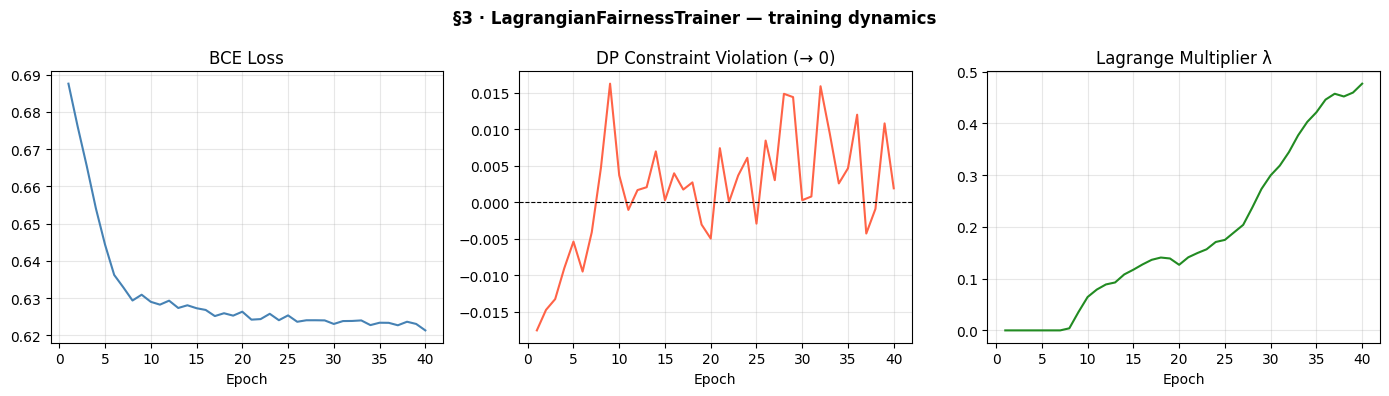

In [13]:
# ── Training curve: multiplier and constraint violation over epochs ────────────
epochs_log  = list(range(1, len(trainer_lag.history) + 1))
violations  = [h['constraints'][0] for h in trainer_lag.history]
multipliers_log = [h['multipliers'][0] for h in trainer_lag.history]
bces        = [h['bce']          for h in trainer_lag.history]

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(14, 4))

ax1.plot(epochs_log, bces, color='steelblue')
ax1.set_title('BCE Loss'); ax1.set_xlabel('Epoch'); ax1.grid(True, alpha=0.3)

ax2.plot(epochs_log, violations, color='tomato')
ax2.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax2.set_title('DP Constraint Violation (→ 0)'); ax2.set_xlabel('Epoch'); ax2.grid(True, alpha=0.3)

ax3.plot(epochs_log, multipliers_log, color='forestgreen')
ax3.set_title('Lagrange Multiplier λ'); ax3.set_xlabel('Epoch'); ax3.grid(True, alpha=0.3)

plt.suptitle('§3 · LagrangianFairnessTrainer — training dynamics', fontweight='bold')
plt.tight_layout()
plt.savefig('section3_lagrangian.png', dpi=120, bbox_inches='tight')
plt.show()

In [14]:
# ── Equalized Odds variant ────────────────────────────────────────────────────
torch.manual_seed(SEED)
model_eo = make_mlp()

y_tr_t = torch.tensor(y_tr)
trainer_eo = LagrangianFairnessTrainer(
    model=model_eo,
    constraint_fns=[equalized_odds_constraint],
    model_lr=1e-3,
    multiplier_lr=5e-3,
    constraint_slack=0.02,
)
trainer_eo.fit(train_dl, epochs=30, verbose=False)

eo_proba2 = trainer_eo.predict_proba(torch.tensor(X_val))
print('=== LagrangianFairnessTrainer (EqualizedOdds) ===')
print(f'  Accuracy : {accuracy_score(y_val, eo_proba2>=0.5):.4f}')
print(f'  DP Gap   : {dp_gap(eo_proba2, s_val):.4f}')

=== LagrangianFairnessTrainer (EqualizedOdds) ===
  Accuracy : 0.6440
  DP Gap   : 0.0072


---
## 4 · GroupFairnessCalibrator  (post-training calibration)

After training, a biased model can still be post-calibrated per group.
We compare **Platt Scaling**, **Isotonic Regression**, and **Temperature
Scaling** (stretch goal for neural net logits).

In [15]:
from calibrator import GroupFairnessCalibrator, PlattScaler, IsotonicScaler, TemperatureScaler

# Use the unconstrained MLP (eta=0) as the biased base model
base_mlp = reg_results[0.0][2]
base_mlp.eval()

with torch.no_grad():
    X_tr_t  = torch.tensor(X_tr)
    X_val_t = torch.tensor(X_val)
    # Raw scores (probabilities from sigmoid)
    scores_tr  = torch.sigmoid(base_mlp(X_tr_t).squeeze(-1)).numpy()
    scores_val = torch.sigmoid(base_mlp(X_val_t).squeeze(-1)).numpy()
    # Raw logits (for temperature scaling)
    logits_tr  = base_mlp(X_tr_t).squeeze(-1).numpy()
    logits_val = base_mlp(X_val_t).squeeze(-1).numpy()

print(f'Uncalibrated  Accuracy: {accuracy_score(y_val, scores_val>=0.5):.4f}')
print(f'Uncalibrated  DP Gap  : {dp_gap(scores_val, s_val):.4f}')

Uncalibrated  Accuracy: 0.6820
Uncalibrated  DP Gap  : 0.0402


In [16]:
# ── Platt Scaling ─────────────────────────────────────────────────────────────
cal_platt = GroupFairnessCalibrator(method='platt')
cal_platt.fit(scores_tr, y_tr, groups=s_tr)
platt_proba = cal_platt.predict_proba(scores_val, groups=s_val)

print('=== Platt Scaling ===')
print(f'  Accuracy : {accuracy_score(y_val, platt_proba>=0.5):.4f}')
print(f'  DP Gap   : {dp_gap(platt_proba, s_val):.4f}')
print(cal_platt.summary())

=== Platt Scaling ===
  Accuracy : 0.8500
  DP Gap   : 0.6323
=== GroupFairnessCalibrator ===
  Group 0.0: PlattScaler
  Group 1.0: PlattScaler


In [17]:
# ── Isotonic Regression ───────────────────────────────────────────────────────
cal_iso = GroupFairnessCalibrator(method='isotonic')
cal_iso.fit(scores_tr, y_tr, groups=s_tr)
iso_proba = cal_iso.predict_proba(scores_val, groups=s_val)

print('=== Isotonic Regression ===')
print(f'  Accuracy : {accuracy_score(y_val, iso_proba>=0.5):.4f}')
print(f'  DP Gap   : {dp_gap(iso_proba, s_val):.4f}')

=== Isotonic Regression ===
  Accuracy : 0.8500
  DP Gap   : 0.6380


In [18]:
# ── Temperature Scaling (stretch goal) ───────────────────────────────────────
cal_temp = GroupFairnessCalibrator(method='temperature')
cal_temp.fit(logits_tr, y_tr, groups=s_tr)  # expects raw logits
temp_proba = cal_temp.predict_proba(logits_val, groups=s_val)

print('=== Temperature Scaling (stretch) ===')
print(f'  Accuracy : {accuracy_score(y_val, temp_proba>=0.5):.4f}')
print(f'  DP Gap   : {dp_gap(temp_proba, s_val):.4f}')
print(cal_temp.summary())

=== Temperature Scaling (stretch) ===
  Accuracy : 0.6820
  DP Gap   : 0.0414
=== GroupFairnessCalibrator ===
  Group 0.0: TemperatureScaler (T=1.0001)
  Group 1.0: TemperatureScaler (T=0.9467)


In [19]:
# ── Mixed calibration (different method per group) ────────────────────────────
cal_mixed = GroupFairnessCalibrator(
    method='platt',
    group_methods={0: 'isotonic', 1: 'temperature'},
)
cal_mixed.fit(logits_tr, y_tr, groups=s_tr)
mixed_proba = cal_mixed.predict_proba(logits_val, groups=s_val)

print('=== Mixed Calibration (group 0→isotonic, group 1→temperature) ===')
print(f'  Accuracy : {accuracy_score(y_val, mixed_proba>=0.5):.4f}')
print(f'  DP Gap   : {dp_gap(mixed_proba, s_val):.4f}')
print(cal_mixed.summary())

=== Mixed Calibration (group 0→isotonic, group 1→temperature) ===
  Accuracy : 0.7920
  DP Gap   : 0.3421
=== GroupFairnessCalibrator ===
  Group 0.0: IsotonicScaler
  Group 1.0: TemperatureScaler (T=0.9467)


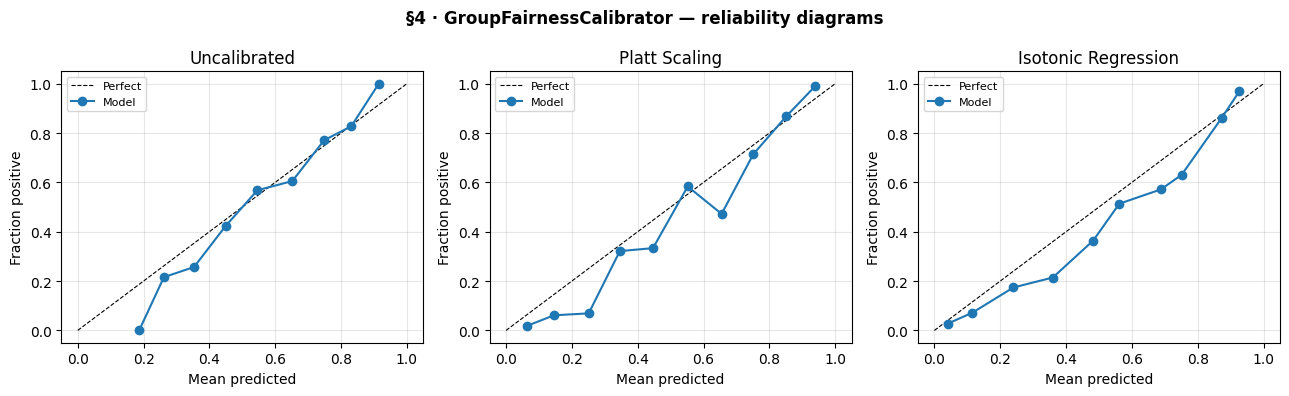

In [20]:
# ── Calibration reliability diagram (per group) ───────────────────────────────
def reliability_diagram(ax, proba, labels, title, n_bins=10):
    bins = np.linspace(0, 1, n_bins + 1)
    mean_pred, mean_true = [], []
    for lo, hi in zip(bins[:-1], bins[1:]):
        mask = (proba >= lo) & (proba < hi)
        if mask.sum() > 0:
            mean_pred.append(proba[mask].mean())
            mean_true.append(labels[mask].mean())
    ax.plot([0, 1], [0, 1], 'k--', lw=0.8, label='Perfect')
    ax.plot(mean_pred, mean_true, 'o-', label='Model')
    ax.set_title(title); ax.set_xlabel('Mean predicted'); ax.set_ylabel('Fraction positive')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
reliability_diagram(axes[0], scores_val, y_val, 'Uncalibrated')
reliability_diagram(axes[1], platt_proba, y_val, 'Platt Scaling')
reliability_diagram(axes[2], iso_proba,   y_val, 'Isotonic Regression')

plt.suptitle('§4 · GroupFairnessCalibrator — reliability diagrams', fontweight='bold')
plt.tight_layout()
plt.savefig('section4_calibration.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 5 · Pareto Frontier Visualisation

`plot_pareto_frontier` trains a fresh model per η, evaluates it, and
overlays the Pareto-efficient models on the fairness-accuracy scatter plot.

  Training η=0.0 ... Acc=0.6780  DP-Gap=0.0441
  Training η=0.05 ... Acc=0.6800  DP-Gap=0.0442
  Training η=0.1 ... Acc=0.6760  DP-Gap=0.0446
  Training η=0.3 ... Acc=0.6760  DP-Gap=0.0414
  Training η=0.5 ... Acc=0.6820  DP-Gap=0.0444
  Training η=1.0 ... Acc=0.6780  DP-Gap=0.0435
  Training η=2.0 ... Acc=0.6700  DP-Gap=0.0421
  Training η=4.0 ... Acc=0.6640  DP-Gap=0.0407


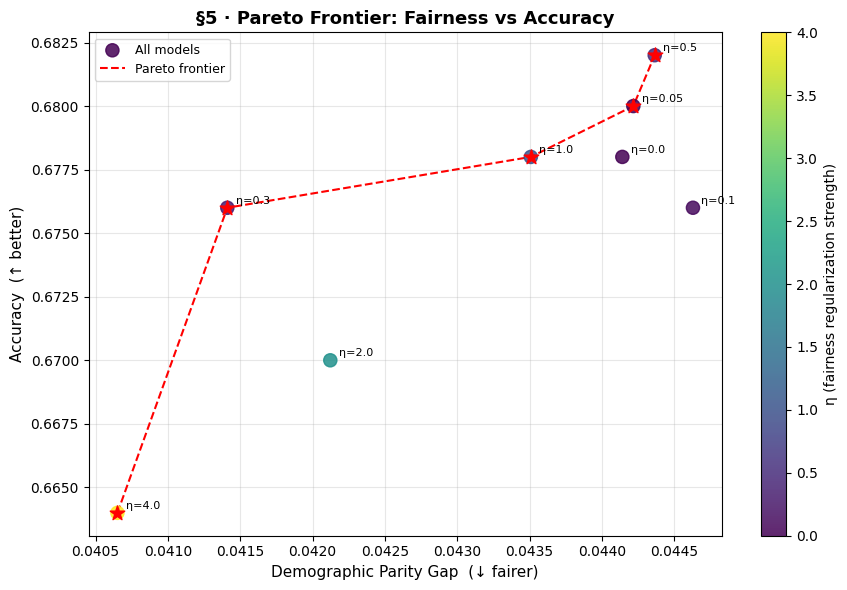


Plot saved → section5_pareto.png

Results table:
     η    Accuracy      DP Gap
--------------------------------
  0.00      0.6780      0.0441
  0.05      0.6800      0.0442
  0.10      0.6760      0.0446
  0.30      0.6760      0.0414
  0.50      0.6820      0.0444
  1.00      0.6780      0.0435
  2.00      0.6700      0.0421
  4.00      0.6640      0.0407


In [23]:
from pareto import plot_pareto_frontier

results = plot_pareto_frontier(
    model_fn=lambda: make_mlp(),
    train_loader=train_dl,
    val_loader=val_dl,
    eta_values=[0.0, 0.05, 0.1, 0.3, 0.5, 1.0, 2.0, 4.0],
    device='cpu',
    epochs=30,
    lr=1e-3,
    sensitive_key='sensitive',
    save_path='section5_pareto.png',
    title='§5 · Pareto Frontier: Fairness vs Accuracy',
)

print('\nResults table:')
print(f'{"η":>6}  {"Accuracy":>10}  {"DP Gap":>10}')
print('-' * 32)
for eta, acc, gap in results:
    print(f'{eta:>6.2f}  {acc:>10.4f}  {gap:>10.4f}')

---
## 6 · AdversarialDebiasingTrainer  *(stretch goal)*

The GRL forces the encoder to produce representations that are
simultaneously **predictive of the label** and **uninformative about the
sensitive attribute**, through a minimax game.

In [25]:
from adversarial import AdversarialDebiasingTrainer, GradientReversalLayer

IN_DIM, ENC_DIM = 4, 32

# Architecture: Encoder + Predictor head + Adversary head
encoder       = nn.Sequential(nn.Linear(IN_DIM, ENC_DIM), nn.ReLU(),
                               nn.Linear(ENC_DIM, ENC_DIM), nn.ReLU())
predictor_head= nn.Linear(ENC_DIM, 1)
adversary_head= nn.Sequential(nn.Linear(ENC_DIM, 16), nn.ReLU(), nn.Linear(16, 1))

adv_trainer = AdversarialDebiasingTrainer(
    encoder=encoder,
    predictor_head=predictor_head,
    adversary_head=adversary_head,
    adversary_input='representation',
    alpha=1.0,
    model_lr=1e-3,
    adversary_lr=5e-4,
    device='cpu',
)
print('GRL layer:', adv_trainer.grl)

GRL layer: GradientReversalLayer(alpha=1.0)


In [26]:
# ── Gradually increase alpha for training stability ───────────────────────────
EPOCHS = 40
alpha_schedule = np.linspace(0.1, 2.0, EPOCHS).tolist()

adv_trainer.fit(
    train_dl,
    epochs=EPOCHS,
    alpha_schedule=alpha_schedule,
    verbose=True,
)

Epoch   1/40 | Pred Loss: 0.6786 | Adv Loss: 0.6953 | α=0.100
Epoch   2/40 | Pred Loss: 0.6650 | Adv Loss: 0.6942 | α=0.149
Epoch   3/40 | Pred Loss: 0.6539 | Adv Loss: 0.6934 | α=0.197
Epoch   4/40 | Pred Loss: 0.6463 | Adv Loss: 0.6929 | α=0.246
Epoch   5/40 | Pred Loss: 0.6383 | Adv Loss: 0.6928 | α=0.295
Epoch   6/40 | Pred Loss: 0.6321 | Adv Loss: 0.6928 | α=0.344
Epoch   7/40 | Pred Loss: 0.6305 | Adv Loss: 0.6929 | α=0.392
Epoch   8/40 | Pred Loss: 0.6275 | Adv Loss: 0.6930 | α=0.441
Epoch   9/40 | Pred Loss: 0.6278 | Adv Loss: 0.6929 | α=0.490
Epoch  10/40 | Pred Loss: 0.6255 | Adv Loss: 0.6928 | α=0.538
Epoch  11/40 | Pred Loss: 0.6260 | Adv Loss: 0.6926 | α=0.587
Epoch  12/40 | Pred Loss: 0.6251 | Adv Loss: 0.6926 | α=0.636
Epoch  13/40 | Pred Loss: 0.6252 | Adv Loss: 0.6926 | α=0.685
Epoch  14/40 | Pred Loss: 0.6248 | Adv Loss: 0.6926 | α=0.733
Epoch  15/40 | Pred Loss: 0.6260 | Adv Loss: 0.6925 | α=0.782
Epoch  16/40 | Pred Loss: 0.6226 | Adv Loss: 0.6926 | α=0.831
Epoch  1

In [27]:
adv_proba = adv_trainer.predict_proba(torch.tensor(X_val))
adv_preds = adv_trainer.predict(torch.tensor(X_val))

print('=== AdversarialDebiasingTrainer ===')
print(f'  Accuracy : {accuracy_score(y_val, adv_preds):.4f}')
print(f'  DP Gap   : {dp_gap(adv_proba, s_val):.4f}')

# Inspect representations
reps = adv_trainer.get_representation(torch.tensor(X_val))
print(f'  Repr shape: {reps.shape}')

=== AdversarialDebiasingTrainer ===
  Accuracy : 0.6640
  DP Gap   : 0.0419
  Repr shape: (500, 32)


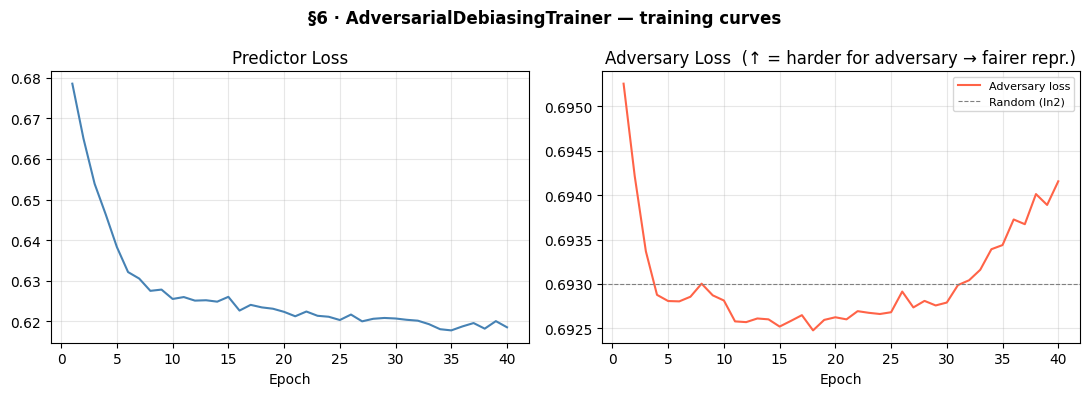


When adversary loss → ln(2) ≈ 0.693, the encoder has become uninformative
about the sensitive attribute (random guessing).


In [28]:
# ── Training curves ──────────────────────────────────────────────────────────
pred_losses = [h['pred_loss'] for h in adv_trainer.history]
adv_losses  = [h['adv_loss']  for h in adv_trainer.history]
ep_range    = range(1, len(pred_losses)+1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(ep_range, pred_losses, label='Predictor loss', color='steelblue')
ax1.set_title('Predictor Loss'); ax1.set_xlabel('Epoch'); ax1.grid(True, alpha=0.3)

ax2.plot(ep_range, adv_losses, label='Adversary loss', color='tomato')
ax2.set_title('Adversary Loss  (↑ = harder for adversary → fairer repr.)'); ax2.set_xlabel('Epoch'); ax2.grid(True, alpha=0.3)
ax2.axhline(0.693, color='grey', linestyle='--', lw=0.8, label='Random (ln2)')
ax2.legend(fontsize=8)

plt.suptitle('§6 · AdversarialDebiasingTrainer — training curves', fontweight='bold')
plt.tight_layout()
plt.savefig('section6_adversarial.png', dpi=120, bbox_inches='tight')
plt.show()
print('\nWhen adversary loss → ln(2) ≈ 0.693, the encoder has become uninformative')
print('about the sensitive attribute (random guessing).')

---
## 7 · Summary Comparison

All methods side-by-side on the same validation set.

Method                                 Accuracy      DP Gap
────────────────────────────────────────────────────────────
Baseline XGBoost                         0.6520      0.0474
Reductions (DP)                          0.6740      0.0632
FairnessRegularizer η=0.5                0.6780      0.0398
LagrangianTrainer (DP)                   0.6820      0.0393
Calibrated (Platt)                       0.8500      0.6323
Adversarial Debiasing                    0.6640      0.0419


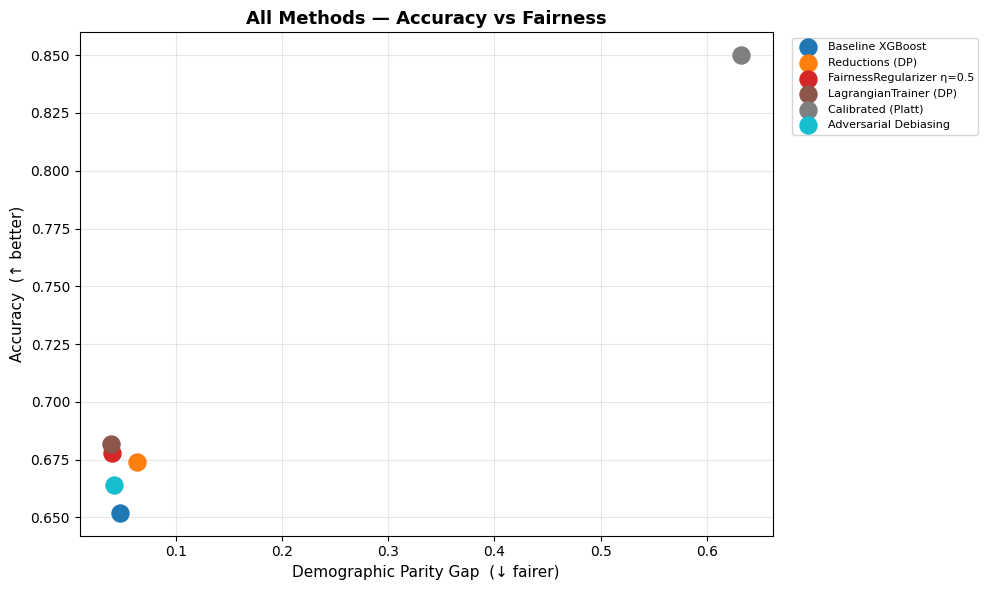

In [32]:
summary = [
    ('Baseline XGBoost',              accuracy_score(y_val, base_preds),   dp_gap(base_proba, s_val)),
    ('Reductions (DP)',                accuracy_score(y_val, dp_preds),    dp_gap(dp_proba, s_val)),
    ('FairnessRegularizer η=0.5',     reg_results[0.5][0],                reg_results[0.5][1]),
    ('LagrangianTrainer (DP)',         accuracy_score(y_val, lag_preds),   dp_gap(lag_proba, s_val)),
    ('Calibrated (Platt)',             accuracy_score(y_val, platt_proba>=0.5), dp_gap(platt_proba, s_val)),
    ('Adversarial Debiasing',          accuracy_score(y_val, adv_preds),  dp_gap(adv_proba, s_val)),
]

print(f'{"Method":<35}  {"Accuracy":>10}  {"DP Gap":>10}')
print('─' * 60)
for name, acc, gap in summary:
    print(f'{name:<35}  {acc:>10.4f}  {gap:>10.4f}')

# ── Visual summary ─────────────────────────────────────────────────────────────
names = [s[0] for s in summary]
accs_ = [s[1] for s in summary]
gaps_ = [s[2] for s in summary]

fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.colormaps["tab10"](np.linspace(0, 0.9, len(summary)))
for i, (name, acc, gap) in enumerate(summary):
    ax.scatter(gap, acc, color=colors[i], s=150, zorder=4, label=name)
ax.set_xlabel('Demographic Parity Gap  (↓ fairer)', fontsize=11)
ax.set_ylabel('Accuracy  (↑ better)', fontsize=11)
ax.set_title('All Methods — Accuracy vs Fairness', fontsize=13, fontweight='bold')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('section7_summary.png', dpi=120, bbox_inches='tight')
plt.show()